<a href="https://colab.research.google.com/github/Hernandez484/01.01-PROYECTO-KAGGLE/blob/main/03%20-%20preprocesado1%20con%20arbol%20de%20decision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

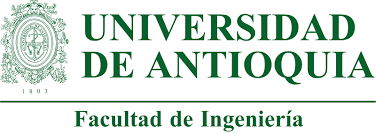

# <font color='056938'> **01.01 - PROYECTO KAGGLE - </font> <font color='8EC044'> Entrega Final "Preprocesado_1 con Árbol de Decision"** </font>

## <font color='157699'> **Paso 1:** </font>

In [1]:
!wget --no-cache -O init.py -q https://raw.githubusercontent.com/rramosp/ai4eng.v1/main/content/init.py
import init; init.init(force_download=False); init.get_weblink()

## <font color='157699'> **Paso 2: Descargar datos directamente desde Kaggle** </font>

- Se creo un archivo kaggle.jsoncon con mi token de autenticación (en kaggle $\to$ Hago clic en el icono de usuario en la parte superior derecha $\to$
ajustes $\to$ API crea un nuevo token);

- Subirlo a este espacio de trabajo del cuaderno;

- Y ejecutar la siguiente celda.

In [2]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '.'
!chmod 600 ./kaggle.json
!kaggle competitions download --force udea-ai-4-eng-20252-pruebas-saber-pro-colombia

  0% 0.00/29.9M [00:00<?, ?B/s]
100% 29.9M/29.9M [00:00<00:00, 1.46GB/s]


## <font color='157699'> **Paso 3: Descomprimir e inspeccionar datos** </font>

Se descomprime el fichero.

In [3]:
!unzip udea*.zip > /dev/null

replace submission_example.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


In [4]:
!wc *.csv

   661081    661468 455032369 preprocesamiento_1.csv
   296787    296787   4716673 submission_example.csv
   296787   4565553  59185238 test.csv
   692501  10666231 143732437 train.csv
  1947156  16190039 662666717 total


## <font color='157699'> **Paso 4: Se carga `train.csv` con la librería `Pandas`** </font>

In [5]:
import pandas as pd
import numpy as np

z = pd.read_csv("train.csv")
print ("shape of loaded dataframe", z.shape)
test = pd.read_csv("test.csv")
print ("shape of loaded dataframe", test.shape)

shape of loaded dataframe (692500, 21)
shape of loaded dataframe (296786, 20)


Se muestran las primeras filas del archivo `train`.

In [6]:
z.head()

,ID,PERIODO_ACADEMICO,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,...,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_TIENEINTERNET.1,F_EDUCACIONMADRE,RENDIMIENTO_GLOBAL,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4
0,904256,20212,ENFERMERIA,BOGOTÁ,Entre 5.5 millones y menos de 7 millones,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica incompleta,Si,...,N,No,Si,Si,Postgrado,medio-alto,0.322,0.208,0.310,0.267
1,645256,20212,DERECHO,ATLANTICO,Entre 2.5 millones y menos de 4 millones,0,Estrato 3,No,Técnica o tecnológica completa,Si,...,N,No,Si,No,Técnica o tecnológica incompleta,bajo,0.311,0.215,0.292,0.264
2,308367,20203,MERCADEO Y PUBLICIDAD,BOGOTÁ,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 3,Si,Secundaria (Bachillerato) completa,Si,...,N,No,No,Si,Secundaria (Bachillerato) completa,bajo,0.297,0.214,0.305,0.264
3,470353,20195,ADMINISTRACION DE EMPRESAS,SANTANDER,Entre 4 millones y menos de 5.5 millones,0,Estrato 4,Si,No sabe,Si,...,N,No,Si,Si,Secundaria (Bachillerato) completa,alto,0.485,0.172,0.252,0.190
4,989032,20212,PSICOLOGIA,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 3,Si,Primaria completa,Si,...,N,No,Si,Si,Primaria completa,medio-bajo,0.316,0.232,0.285,0.294


**Información general**

Considerando que se tiene en total 692K elementos de datos, se tiene relativamente pocos valores faltantes en cada columna.

In [7]:
z.isna().sum()

,0
ID,0
PERIODO_ACADEMICO,0
E_PRGM_ACADEMICO,0
E_PRGM_DEPARTAMENTO,0
E_VALORMATRICULAUNIVERSIDAD,6287
E_HORASSEMANATRABAJA,30857
F_ESTRATOVIVIENDA,32137
F_TIENEINTERNET,26629
F_EDUCACIONPADRE,23178
F_TIENELAVADORA,39773


In [8]:
z.dtypes

,0
ID,int64
PERIODO_ACADEMICO,int64
E_PRGM_ACADEMICO,object
E_PRGM_DEPARTAMENTO,object
E_VALORMATRICULAUNIVERSIDAD,object
E_HORASSEMANATRABAJA,object
F_ESTRATOVIVIENDA,object
F_TIENEINTERNET,object
F_EDUCACIONPADRE,object
F_TIENELAVADORA,object


**Revisión de columnas**

**Periodo**

Posibilidades:
* Se puede separar el año del periodo en dos columnas y trabajarlo en numeros(Recomendado por el Profe) o como etiquetas.
* Trabajar los periodos como etiquetas o numeros.

**Nota:** Trabarla como etiquetas no nos permitiria predecir cosas que esten por fuera de esos periodos. Puede ser util para que el modelo tenga más capacidad de predecir los valores del test(Y sacar un mejor Acurracy), pero podria generar un sobre ajuste.

In [9]:
sorted(z.PERIODO_ACADEMICO.unique())

[np.int64(20183),
 np.int64(20184),
 np.int64(20194),
 np.int64(20195),
 np.int64(20196),
 np.int64(20202),
 np.int64(20203),
 np.int64(20212),
 np.int64(20213)]

In [10]:
sorted(test.PERIODO_ACADEMICO.unique())

[np.int64(20183),
 np.int64(20184),
 np.int64(20194),
 np.int64(20195),
 np.int64(20196),
 np.int64(20202),
 np.int64(20203),
 np.int64(20212),
 np.int64(20213)]

**Tratamiendo de columna: Eliminación**

In [11]:
z = z.drop(columns=['PERIODO_ACADEMICO'])

In [12]:
z.head()

,ID,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_TIENEINTERNET.1,F_EDUCACIONMADRE,RENDIMIENTO_GLOBAL,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4
0,904256,ENFERMERIA,BOGOTÁ,Entre 5.5 millones y menos de 7 millones,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica incompleta,Si,Si,N,No,Si,Si,Postgrado,medio-alto,0.322,0.208,0.310,0.267
1,645256,DERECHO,ATLANTICO,Entre 2.5 millones y menos de 4 millones,0,Estrato 3,No,Técnica o tecnológica completa,Si,No,N,No,Si,No,Técnica o tecnológica incompleta,bajo,0.311,0.215,0.292,0.264
2,308367,MERCADEO Y PUBLICIDAD,BOGOTÁ,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 3,Si,Secundaria (Bachillerato) completa,Si,No,N,No,No,Si,Secundaria (Bachillerato) completa,bajo,0.297,0.214,0.305,0.264
3,470353,ADMINISTRACION DE EMPRESAS,SANTANDER,Entre 4 millones y menos de 5.5 millones,0,Estrato 4,Si,No sabe,Si,No,N,No,Si,Si,Secundaria (Bachillerato) completa,alto,0.485,0.172,0.252,0.190
4,989032,PSICOLOGIA,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 3,Si,Primaria completa,Si,Si,N,No,Si,Si,Primaria completa,medio-bajo,0.316,0.232,0.285,0.294


**Programa Academico**

**Importante:** Una posible opción es clasificar las carreras como Ingenieria, Licenciatura, Ciencias Exactas, etc. Son muchas carreras para hacer onehot.

* El examen tiene areas como matematicas, Lectura Crítica, Sociales y Ciudadanas, ciencias naturales e ingles tal vez eso ayude a predecir.
* Buscar carreras con una distancia de edicion cortas como posibles carreras duplicadas.
*(¿Otras ideas?)

In [13]:
len(sorted(z.E_PRGM_ACADEMICO.unique()))

948

**Nota:** En este caso decidimos por organizar por tematica principal


In [14]:
len(z.E_PRGM_ACADEMICO.unique())

948

Tratamiento de columna: Reducción de etiqueta, mapeo y variable nominal

In [15]:
import re

In [16]:
# Function to clean the data, removing accents and special characters and converting to lowercase
def sanitize(text: str):
    accentA = re.compile(r'[áàâãä]'), 'a'
    accentE = re.compile(r'[éèêë]'), 'e'
    accentI = re.compile(r'[íìîï]'), 'i'
    accentO = re.compile(r'[óòôõö]'), 'o'
    accentU = re.compile(r'[úùûü]'), 'u'
    ampersand = re.compile(r'&'), 'y'

    removeSimbols = lambda text: ''.join(re.split(r'[,.:;[\]{}()?¿!¡°\'\"\n_-]', text))
    removeNumbers = lambda text: re.sub(r'\d', '', text)

    removeDoubleSpaces = lambda text: re.sub(r'  ', ' ', text)
    removeBeginSpaces = lambda text: re.sub(r'^\s', '', text)
    accentsToNormal = lambda accent, text: re.sub(accent[0], accent[1], text)
    removeKeywords = lambda keywords, text: re.sub(r'|'.join(keywords), '', text)

    text = text.lower()
    text = removeSimbols(text)
    text = removeNumbers(text)
    text = accentsToNormal(accentA, text)
    text = accentsToNormal(accentE, text)
    text = accentsToNormal(accentI, text)
    text = accentsToNormal(accentO, text)
    text = accentsToNormal(accentU, text)
    text = accentsToNormal(ampersand, text)
    text = removeDoubleSpaces(text)
    text = removeBeginSpaces(text)

    text = removeDoubleSpaces(text)
    text = removeBeginSpaces(text)

    for _ in range(0, 5):
        text = removeDoubleSpaces(text)

    return text
# Edit distance between 2 words
def edit_dist(s1, s2, maxDist = None):
    m, n = len(s1), len(s2)
    prev = 0  # Stores dp[i-1][j-1]
    curr = list(range(n + 1))  # Stores dp[i][j-1] and dp[i][j]

    for i in range(1, m + 1):
        prev = curr[0]
        curr[0] = i

        for j in range(1, n + 1):
            temp = curr[j]
            if s1[i - 1] == s2[j - 1]:
                curr[j] = prev
            else:
                curr[j] = 1 + min(curr[j - 1], prev, curr[j])
            prev = temp

        if maxDist is not None and min(curr) > maxDist:
            return maxDist + 1

    return curr[n]
# Tries to link words that might be the same idea
def absorb(wordsDict, maxDistance):
    words = wordsDict.copy()
    keys = list(words.keys())
    keyCount = len(keys)

    for i in range(keyCount):
        for j in range(i + 1, keyCount):
            dist = edit_dist(keys[i], keys[j], maxDistance)

            if dist <= maxDistance:
                words[keys[i]]['similar'].append(keys[j])
                continue

    return words

In [17]:
# Dict comprehension to create a dictionary with a unique id for each career and a json object with the career name
data = sorted(z.E_PRGM_ACADEMICO.unique())
data = {i: {'name': career, 'sanitized': sanitize(career), 'same': []} for i, career in enumerate(data)}

In [18]:
# If the sanitized name is the same for two careers, the careers are the same, then we add the id of the career to the list of the first career with the same sanitized name
for i, career in data.items():
    for j in range(i + 1, len(data)):
        if edit_dist(career['sanitized'], data[j]['sanitized'], 0) <= 0:
            data[i]['same'] = data[i]['same'] + [j]

In [19]:
def mergeSame(d):
  toRemove = []

  for i, career in d.items():
      hasWork = len(career['same']) != 0
      toUse = []

      while hasWork:
        hasWork = False
        toUse = d[i]['same'][len(toUse) - 1:]

        for rep in toUse:
            if len(d[rep]['same']) != 0:
              hasWork = True
              d[i]['same'] += d[rep]['same']

            toRemove.append(rep)

  for e in toRemove:
      if e in d:
          del d[e]

In [20]:
mergeSame(data)
print(len(data))

793


In [21]:
c = 0
for i, career in data.items():
    if len(career['same']) == 0:
        continue

    print(f"{i}: {(career['same'])}")
    c += 1

print(c)

4: [50, 97]
11: [76]
13: [79]
14: [80]
16: [82]
17: [83]
21: [84, 86]
22: [23, 87]
23: [87]
34: [74, 90]
35: [92]
37: [38]
48: [93]
50: [97]
54: [55]
56: [100, 101]
59: [102]
61: [103]
63: [104]
64: [66, 105, 107]
65: [106]
66: [105, 107]
70: [108]
74: [90]
84: [86]
100: [101]
105: [107]
114: [115]
126: [127]
129: [132]
131: [133]
142: [143]
144: [148]
145: [149]
154: [158]
155: [159]
174: [175]
179: [180]
188: [212]
193: [216]
194: [217]
195: [200, 220]
196: [197, 198, 199, 201, 218]
197: [198, 199, 201, 218]
198: [199, 201, 218]
199: [201, 218]
200: [220]
201: [218]
229: [233, 235, 236, 237]
233: [235, 236, 237]
235: [236, 237]
236: [237]
250: [251]
277: [279, 280]
279: [280]
292: [294]
295: [299]
300: [301]
304: [305]
312: [313]
317: [320]
318: [321]
327: [334]
335: [337]
342: [344]
350: [355]
364: [371]
365: [376, 484]
366: [384, 488]
368: [477]
369: [483]
370: [478]
372: [479]
373: [374, 480, 481]
374: [480, 481]
375: [482]
376: [484]
378: [485]
380: [381, 486]
381: [486]
384: [48

In [22]:
# We generate a dict with each important words of the careers to describe them
# The dict has the word as key and the values are the number of times the word appears in the careers and the number of times the word appears first in the careers
words = {}
meaningless = ['como', 'ocupacional', 'ciclo', 'ciclos', 'para', 'profesional', 'tecnico', 'tecnologo', 'tecnologia', 'tecnologias', 'tecnica', 'tecnologica', 'tecnologicas', 'tecnologicos', 'tecnologico', 'actividad']
for i, career in data.items():
    candidates = career['sanitized'].split(' ')

    for candidate in candidates:
        if candidate in meaningless or len(candidate) <= 3:
            continue

        isCandidateFirst = candidate == candidates[0]

        if candidate not in words:
            baseTotal = len(career['same']) + 1
            baseFirst = baseTotal + 1 if isCandidateFirst else 0
            words[candidate] = {'total': baseTotal, 'first': baseFirst, 'similar': []}

        else:
          words[candidate]['total'] += 1

          if isCandidateFirst:
              words[candidate]['first'] += 1

In [23]:
# Now we will look all the possible keys that a program can have and only keep the one that is the most popular
# The popular keys will be stored in a separate array, so any key not present in the array will be discarted

toKeep = []
for i, career in data.items():
    candidates = career['sanitized'].split(' ')
    mostPopular = None

    for candidate in candidates:
        if candidate not in words:
            continue

        elif mostPopular is None:
            mostPopular = candidate

        elif words[candidate]['total'] > words[mostPopular]['total']:
            mostPopular = candidate

    toKeep.append(mostPopular)

for key in list(words.keys()):
    if key not in toKeep:
        del words[key]

In [24]:
len(words)

132

In [25]:
for candidate in words:
    print(candidate)

print(f"El numero de candidatos son {len(words)}")

negocios
internacionales
fisica
deporte
acuicultura
administracion
ambiental
mercadeo
comercio
empresas
gestion
turistica
finanzas
turismo
seguridad
social
salud
logistica
sistemas
internacional
deportiva
produccion
enfasis
industrial
publica
direccion
administracin
agronegocios
arquitectura
agronomia
animacion
antropologia
archivistica
arqueologia
arte
artes
gastronomia
musical
astronomia
bacteriologia
bibliotecologia
bioingenieria
biologia
bioquimica
biotecnologia
ciencia
informacion
gobierno
ciencias
computacion
recreacion
educacion
cine
comunicacion
periodismo
visual
comunicaciones
comunicacin
medios
digitales
conservacion
construccion
ingenieria
construcciones
contaduria
economia
creacion
criminalistica
danza
derecho
desarrollo
grafico
diseo
diseño
realizacion
ecologia
economa
enfermeria
entrenamiento
español
filologia
estadistica
estudios
filosofia
farmacia
humanidades
fisioterapia
fonoaudiologia
fotografia
geociencias
geografia
geologia
geologa
gerontologia
historia
software
ins

In [26]:
# Now we compare the words with each other to see if they are similar (edit distance)
# If the edit distance is less than 3, we consider the words similar and combine the results in a single word
# Finally, the resulting dict will have a 3rd value with the similar words it absorbed
# Final dict: {word: {total: int, first: int, similar: [word1, word2, ...]}}

words = absorb(words, 4)

# Sort the dict by the number of times the word appears first in the careers
words = {k: v for k, v in sorted(words.items(), key=lambda item: item[1]['first'], reverse=False)}
print(len(words))

132


In [27]:
c = 0
for candidate, info in words.items():
    if len(info['similar']) == 0:
        continue

    print(f'{candidate}: {info}')
    c += 1

print(c)

internacionales: {'total': 32, 'first': 0, 'similar': ['internacional']}
turistica: {'total': 6, 'first': 0, 'similar': ['turismo', 'logistica', 'estadistica', 'quimica', 'musica']}
social: {'total': 17, 'first': 0, 'similar': ['musical', 'cine', 'visual']}
publica: {'total': 11, 'first': 0, 'similar': ['musical', 'quimica', 'musica', 'publicidad', 'qumica']}
musical: {'total': 4, 'first': 0, 'similar': ['visual', 'quimica', 'musica', 'qumica']}
educacion: {'total': 107, 'first': 0, 'similar': ['creacion', 'traduccion']}
visual: {'total': 8, 'first': 0, 'similar': ['diseo', 'diseño']}
medios: {'total': 7, 'first': 0, 'similar': ['estudios', 'musica', 'medicina']}
fisica: {'total': 33, 'first': 1, 'similar': ['turistica', 'logistica', 'publica', 'musical', 'ciencia', 'visual', 'diseo', 'diseño', 'quimica', 'musica', 'qumica']}
turismo: {'total': 7, 'first': 1, 'similar': ['diseo', 'urbanismo']}
salud: {'total': 18, 'first': 1, 'similar': ['arte', 'danza']}
produccion: {'total': 12, 'fir

In [28]:
# Now iterate over the words showing the results of only the main words with similar words, present the option to accept or reject the merge of the words
# If the merge is rejected, the word will be removed from the list of similar words of the main word
# If the merge is accepted, the similar word will be removed from the list of words and the main word will have the total and first values updated
# If the merge is accepted, the similar words of the similar word will be added to the main word and the similar word will be removed from the list of words

print("Want to merge all without review? (y/n)")
option = "y" #input("> ")

toRemove = []

copy = words.copy()

if option == 'y':
    for candidate, info in words.items():
        for similar in info['similar']:
            words[candidate]['total'] += words[similar]['total']
            words[candidate]['first'] += words[similar]['first']
            words[candidate]['similar'] += words[similar]['similar']
            toRemove.append(similar)

    for e in toRemove:
      if e in words:
          del words[e]

else:
  for candidate, info in words.items():
      option = ""

      if len(info['similar']) == 0:
          continue

      elif len(info['similar']) == 1:
        option = "s"

      else:
        print(f'{candidate}: {info["similar"]}')
        print('Review Type? (a)ll | (s)eparate | (p)artial')
        option = input("> ")

        while option not in ['a', 's', 'p']:
              print(f'{candidate}: {info["similar"]}')
              print("Invalid option, choose again")
              print('Review Type? (a)ll | (s)eparate | (p)artial')
              option = input("> ")

      if option == 'a':
          print('Discard all or merge all? (d)iscard | (m)erge)')
          option = input("> ")

          while option not in ['d', 'm']:
              print(f'{candidate}: {info["similar"]}')
              print("Invalid option, choose again")
              print('Discard all or merge all? (d)iscard | (m)erge)')
              option = input("> ")

          if option == 'd':
              words[candidate]['similar'] = []

          elif option == 'm':
              toRemove += info['similar']

              for similar in info['similar']:
                  words[candidate]['total'] += words[similar]['total']
                  words[candidate]['first'] += words[similar]['first']
                  words[candidate]['similar'] += words[similar]['similar']


      elif option == 'p':
          print('Discard or merge selection? (d)iscard | (m)erge)')
          option = input("> ")

          while option not in ['d', 'm']:
              print(f'{candidate}: {info["similar"]}')
              print("Invalid option, choose again")
              print('Discard all or merge all? (d)iscard | (m)erge)')
              option = input("> ")

          toUse = []
          newWord = ""

          while newWord != 'done':
            texts = {'d': 'discard', 'm': 'merge'}
            print(f"Enter a word to {texts[option]} or 'done' to finish")
            newWord = input("> ")

            if newWord in info["similar"]:
              toUse.append(newWord)

          if option == 'd':
              for similar in toUse:
                  words[candidate]['similar'].remove(similar)

          if option == 'm':
              for similar in toUse:
                  words[candidate]['total'] += words[similar]['total']
                  words[candidate]['first'] += words[similar]['first']
                  words[candidate]['similar'] += words[similar]['similar']
                  toRemove.append(similar)

      elif option == 's':
        dropPending = []

        for i in range(len(info['similar'])):
            size = len(info['similar'])
            similar = info['similar'][i]
            print(f'{i}|{size} - {candidate}: {similar}')
            drop = input('Drop? (y/n): ')

            if drop == 'y':
                dropPending.append(similar)

            else:
                words[candidate]['total'] += words[similar]['total']
                words[candidate]['first'] += words[similar]['first']
                words[candidate]['similar'] += words[similar]['similar']
                toRemove.append(similar)

        for w in dropPending:
            words[candidate]['similar'].remove(w)

for e in toRemove:
    if e in words:
        del words[e]

Want to merge all without review? (y/n)


In [29]:
# Print results
for candidate, info in words.items():
    print(f'{candidate}: {info}')

print(len(words))

internacionales: {'total': 41, 'first': 0, 'similar': ['internacional']}
ambiental: {'total': 25, 'first': 0, 'similar': []}
empresas: {'total': 20, 'first': 0, 'similar': []}
social: {'total': 417, 'first': 257, 'similar': ['musical', 'cine', 'visual', 'visual', 'quimica', 'musica', 'qumica', 'danza', 'diseo', 'diseño', 'diseo', 'diseño', 'diseo', 'diseño', 'quirurgica', 'musica', 'qumica', 'medicina', 'qumica', 'diseo', 'diseño', 'diseño', 'diseño', 'medicina', 'qumica', 'diseño']}
enfasis: {'total': 70, 'first': 0, 'similar': []}
industrial: {'total': 15, 'first': 0, 'similar': []}
digitales: {'total': 4, 'first': 0, 'similar': []}
grafico: {'total': 7, 'first': 0, 'similar': []}
humanidades: {'total': 20, 'first': 0, 'similar': []}
software: {'total': 6, 'first': 0, 'similar': []}
agroindustria: {'total': 2, 'first': 0, 'similar': []}
fisica: {'total': 2896, 'first': 1884, 'similar': ['turistica', 'logistica', 'publica', 'musical', 'ciencia', 'visual', 'diseo', 'diseño', 'quimica',

In [30]:
# Now, we will generate a dict with the words as keys and the values as the id of the careers that use the word as key
# The careers will generate a key with the sanitized name of the career, then split the sanitized name and see the words that are in the words dict
# The word selected will be the one with the highest number in 'first' or if 'first' is 80% of another word 'first' value and wins in 'total' by at least 20%
# The word selected can be the key of the words dict or a similar word
grouped = {}
parentOf = lambda key: key if key in words else next((k for k, v in words.items() if key in v['similar']), 'none')
validKey = lambda key: parentOf(key) != 'none'
unsafePointsOf = lambda word, pointType: words[word][pointType] if word in words else words[parentOf(word)][pointType]
pointsOf = lambda word, pointType: words[word][pointType] if word in words else words[parentOf(word)][pointType] if parentOf(word) != 'none' else 0

for i, career in data.items():
    candidates = career['sanitized'].split(' ')
    selected = None

    for candidate in candidates:
        if validKey(candidate):
            if selected is None:
                selected = candidate
            else:
                hasMoreFirst = unsafePointsOf(candidate, 'first') > unsafePointsOf(selected, 'first')
                isCloseToFirst = unsafePointsOf(candidate, 'first') >= unsafePointsOf(selected, 'first') * 0.8
                isMorePopular = unsafePointsOf(candidate, 'total') >= unsafePointsOf(selected, 'total') * 1.2

                if hasMoreFirst or (isCloseToFirst and isMorePopular):
                    selected = candidate

    if selected is not None:
        grouped[selected] = grouped.get(selected, []) + [i]
        continue

    else:
        print(f'No word selected for {career["name"]}')
        grouped['none'] = grouped.get('none', []) + [i]

print(len(grouped.get('none', [])))

0


In [31]:
# Print the groups formed
for name, group in grouped.items():
    print(f"{name}: {group}")

print(len(grouped))

negocios: [0, 803, 818, 835, 836, 838, 892, 897]
fisica: [1, 241, 242, 246, 247, 248, 327, 448, 553, 585, 589, 599, 602, 631, 645, 646, 647, 648, 649, 650, 651, 669, 690, 698, 718, 763, 842, 857]
acuicultura: [2]
administracion: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16, 17, 18, 19, 21, 22, 23, 25, 27, 28, 31, 33, 34, 36, 37, 40, 43, 47, 50, 51, 52, 53, 54, 57, 58, 59, 60, 63, 70, 74, 75, 77, 78, 81, 84, 85, 91, 98, 859]
comercio: [13, 39, 181, 182, 183, 184, 185, 323, 324]
gestion: [15, 69, 226, 312, 348, 349, 351, 353, 354]
turistica: [20, 64, 65, 66, 105, 109]
finanzas: [24, 44, 68, 138, 139, 322, 325, 326, 837, 863, 882]
turismo: [26, 41, 362, 363, 945]
social: [29, 194, 195, 196, 197, 198, 199, 200, 201, 209, 210, 219, 778, 851, 866, 900, 943]
salud: [30, 35, 48, 49, 88, 89, 94, 95, 96, 99, 346, 441, 513, 888, 902, 930, 931]
logistica: [32, 45, 46, 56, 100, 510, 796, 797, 802]
deportiva: [42, 352]
publica: [61, 62, 229, 231, 233, 235, 236, 850, 867]
direccion: [67, 255, 257, 258, 8

In [32]:
# Finally, it's time to replace the old academic program with the new one
# Here, we will look for the id given to the program
# Then, using the sanitized version, search in which group the id landed, for that we are using binary search
# since, as a side effect of our data processing, all ids are in increasing order, so we are taking advantage of that
# For the look-up, we are creating a generator comprehention, so when we call our search, we only call it the minimun number of times
# until it finds the first match (and only one) and return the result (the name of the new program name as the key)

def binary_search(arr, x):
    low = 0
    high = len(arr) - 1
    mid = 0

    while low <= high:

        mid = (high + low) // 2

        # If x is greater, ignore left half
        if arr[mid] < x:
            low = mid + 1

        # If x is smaller, ignore right half
        elif arr[mid] > x:
            high = mid - 1

        # means x is present at mid
        else:
            return mid

    # If we reach here, then the element was not present
    return -1

mappings = {}

for program in z.E_PRGM_ACADEMICO:
    programId = next((id for id, names in data.items() if names['name'] == program), None)

    if programId is not None:
      posibleKeys = [k for k in data[programId]['sanitized'].split(' ') if k in grouped]
      newKey = next(key for key in posibleKeys if binary_search(grouped[key], programId) != -1)
      mappings[program] = newKey

print(len(mappings))

793


In [33]:
for key, value in mappings.items():
    print(f"{key}: {value}")

ENFERMERIA: enfermeria
DERECHO: derecho
MERCADEO Y PUBLICIDAD: publicidad
ADMINISTRACION DE EMPRESAS: administracion
PSICOLOGIA: psicologia
MEDICINA VETERINARIA: medicina
INGENIERIA MECANICA: ingenieria
ADMINISTRACIÓN EN SALUD OCUPACIONAL: salud
INGENIERIA INDUSTRIAL: ingenieria
HOTELERIA Y TURISMO: turismo
LICENCIATURA EN PEDAGOGIA INFANTIL: licenciatura
COMUNICACION SOCIAL: social
CIENCIA POLITICA: ciencia
PROFESIONAL EN GESTIÓN DE LA SEGURIDAD Y LA SALUD LABORAL: salud
INGENIERIA MECATRONICA: ingenieria
TRABAJO SOCIAL: social
LICENCIATURA EN BIOLOGIA Y EDUCACION AMBIENTAL: biologia
INGENIERIA CIVIL: ingenieria
CONTADURIA PÚBLICA: publica
ADMINISTRACION EN SALUD: salud
ESTADISTICA: estadistica
LICENCIATURA EN BIOLOGIA: biologia
INGENIERIA AGROINDUSTRIAL: ingenieria
ZOOTECNIA: zootecnia
COMUNICACION AUDIOVISUAL: comunicacion
LICENCIATURA EN EDUCACION BASICA CON ENFASIS EN HUMANIDADES-INGLES: licenciatura
COMUNICACION SOCIAL  - PERIODISMO: social
SEGURIDAD Y SALUD EN EL TRABAJO: salud


In [34]:
z['E_PRGM_ACADEMICO'] = z['E_PRGM_ACADEMICO'].replace(mappings)

In [35]:
len(z.E_PRGM_ACADEMICO.unique())

276

In [36]:
sorted(z.E_PRGM_ACADEMICO.unique())

['ADMINISTRACION DE SISTEMAS INFORMÁTICOS',
 'ADMINISTRACION INFORMÁTICA',
 'ADMINISTRACIÓN COMERCIAL',
 'ADMINISTRACIÓN DE COMERCIO EXTERIOR',
 'ADMINISTRACIÓN DE EMPRESAS',
 'ADMINISTRACIÓN DE EMPRESAS AGROINDUSTRIALES',
 'ADMINISTRACIÓN DE EMPRESAS AGROPECUARIAS',
 'ADMINISTRACIÓN DE EMPRESAS TURÍSTICAS',
 'ADMINISTRACIÓN DE EMPRESAS TURÍSTICAS Y HOTELERAS',
 'ADMINISTRACIÓN DE NEGOCIOS INTERNACIONALES',
 'ADMINISTRACIÓN DE SERVICIOS DE SALUD',
 'ADMINISTRACIÓN EN SALUD',
 'ADMINISTRACIÓN FINANCIERA',
 'ADMINISTRACIÓN LOGÍSTICA',
 'ADMINISTRACIÓN MARITIMA Y PORTUARIA',
 'ADMINISTRACIÓN PÚBLICA',
 'ADMINISTRACIÓN TECNÓLOGICA',
 'ADMINISTRACIÓN TURÍSTICA Y HOTELERA',
 'ADMINISTRACIÓN TÚRÍSTICA',
 'ADMINISTRACIÓN Y NEGOCIOS INTERNACIONALES',
 'ANTROPOLOGÍA',
 'ARTES ESCÉNICAS',
 'ARTES PLÁSTICAS',
 'ARTES PLÁSTICAS Y VISUALES',
 'BIOINGENIERÍA',
 'BIOLOGÍA',
 'BIOLOGÍA AMBIENTAL',
 'CIENCIA POLÍTICA',
 'CIENCIA POLÍTICA Y GOBIERNO',
 'CIENCIAS POLÍTICAS',
 'CINE Y TELEVISIÓN',
 'COMUNI

In [37]:
z.E_PRGM_ACADEMICO

,E_PRGM_ACADEMICO
0,enfermeria
1,derecho
2,publicidad
3,administracion
4,psicologia
...,...
692495,biologia
692496,psicologia
692497,salud
692498,psicologia


**OneHot**

In [38]:
df_onehot = pd.get_dummies(z['E_PRGM_ACADEMICO'], prefix='PRGA', dtype=int)
z = pd.concat([z, df_onehot], axis=1)

In [39]:
z.head()

,ID,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,...,PRGA_software,PRGA_teologia,PRGA_terapia,PRGA_terapias,PRGA_traduccion,PRGA_turismo,PRGA_turistica,PRGA_urbanismo,PRGA_visual,PRGA_zootecnia
0,904256,enfermeria,BOGOTÁ,Entre 5.5 millones y menos de 7 millones,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica incompleta,Si,Si,...,0,0,0,0,0,0,0,0,0,0
1,645256,derecho,ATLANTICO,Entre 2.5 millones y menos de 4 millones,0,Estrato 3,No,Técnica o tecnológica completa,Si,No,...,0,0,0,0,0,0,0,0,0,0
2,308367,publicidad,BOGOTÁ,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 3,Si,Secundaria (Bachillerato) completa,Si,No,...,0,0,0,0,0,0,0,0,0,0
3,470353,administracion,SANTANDER,Entre 4 millones y menos de 5.5 millones,0,Estrato 4,Si,No sabe,Si,No,...,0,0,0,0,0,0,0,0,0,0
4,989032,psicologia,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 3,Si,Primaria completa,Si,Si,...,0,0,0,0,0,0,0,0,0,0


In [40]:
z.drop(columns=['E_PRGM_ACADEMICO'], inplace=True)

In [41]:
z.head()

,ID,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,...,PRGA_software,PRGA_teologia,PRGA_terapia,PRGA_terapias,PRGA_traduccion,PRGA_turismo,PRGA_turistica,PRGA_urbanismo,PRGA_visual,PRGA_zootecnia
0,904256,BOGOTÁ,Entre 5.5 millones y menos de 7 millones,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica incompleta,Si,Si,N,...,0,0,0,0,0,0,0,0,0,0
1,645256,ATLANTICO,Entre 2.5 millones y menos de 4 millones,0,Estrato 3,No,Técnica o tecnológica completa,Si,No,N,...,0,0,0,0,0,0,0,0,0,0
2,308367,BOGOTÁ,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 3,Si,Secundaria (Bachillerato) completa,Si,No,N,...,0,0,0,0,0,0,0,0,0,0
3,470353,SANTANDER,Entre 4 millones y menos de 5.5 millones,0,Estrato 4,Si,No sabe,Si,No,N,...,0,0,0,0,0,0,0,0,0,0
4,989032,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 3,Si,Primaria completa,Si,Si,N,...,0,0,0,0,0,0,0,0,0,0


**Departamento**

In [42]:
len(z.E_PRGM_DEPARTAMENTO.unique())

31

In [43]:
len(sorted(z.E_PRGM_DEPARTAMENTO.unique()))

31

**Tratamiendo de columna: Variable nominal**

In [44]:
#Se eliminan los espacios para poder acceder a la variables asi: z.EL_DEPARTAMENTO
z['E_PRGM_DEPARTAMENTO'] = z['E_PRGM_DEPARTAMENTO'].str.replace(' ', '_')
sorted(z.E_PRGM_DEPARTAMENTO.unique())

['AMAZONAS',
 'ANTIOQUIA',
 'ARAUCA',
 'ATLANTICO',
 'BOGOTÁ',
 'BOLIVAR',
 'BOYACA',
 'CALDAS',
 'CAQUETA',
 'CASANARE',
 'CAUCA',
 'CESAR',
 'CHOCO',
 'CORDOBA',
 'CUNDINAMARCA',
 'GUAVIARE',
 'HUILA',
 'LA_GUAJIRA',
 'MAGDALENA',
 'META',
 'NARIÑO',
 'NORTE_SANTANDER',
 'PUTUMAYO',
 'QUINDIO',
 'RISARALDA',
 'SANTANDER',
 'SAN_ANDRES',
 'SUCRE',
 'TOLIMA',
 'VALLE',
 'VAUPES']

**OneHot**

In [45]:
df_onehot = pd.get_dummies(z['E_PRGM_DEPARTAMENTO'], prefix='DEP',dtype=int)
z = pd.concat([z, df_onehot], axis=1)

In [46]:
z.head()

,ID,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,904256,BOGOTÁ,Entre 5.5 millones y menos de 7 millones,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica incompleta,Si,Si,N,...,0,0,0,0,0,0,0,0,0,0
1,645256,ATLANTICO,Entre 2.5 millones y menos de 4 millones,0,Estrato 3,No,Técnica o tecnológica completa,Si,No,N,...,0,0,0,0,0,0,0,0,0,0
2,308367,BOGOTÁ,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 3,Si,Secundaria (Bachillerato) completa,Si,No,N,...,0,0,0,0,0,0,0,0,0,0
3,470353,SANTANDER,Entre 4 millones y menos de 5.5 millones,0,Estrato 4,Si,No sabe,Si,No,N,...,0,0,0,0,1,0,0,0,0,0
4,989032,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 3,Si,Primaria completa,Si,Si,N,...,0,0,0,0,0,0,0,0,0,0


In [47]:
z.drop(columns=['E_PRGM_DEPARTAMENTO'], inplace=True)

In [48]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,904256,Entre 5.5 millones y menos de 7 millones,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica incompleta,Si,Si,N,No,...,0,0,0,0,0,0,0,0,0,0
1,645256,Entre 2.5 millones y menos de 4 millones,0,Estrato 3,No,Técnica o tecnológica completa,Si,No,N,No,...,0,0,0,0,0,0,0,0,0,0
2,308367,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 3,Si,Secundaria (Bachillerato) completa,Si,No,N,No,...,0,0,0,0,0,0,0,0,0,0
3,470353,Entre 4 millones y menos de 5.5 millones,0,Estrato 4,Si,No sabe,Si,No,N,No,...,0,0,0,0,1,0,0,0,0,0
4,989032,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 3,Si,Primaria completa,Si,Si,N,No,...,0,0,0,0,0,0,0,0,0,0


**Decisiones de las columnas con NAN**

**Con el precio de la matricula**

Posibildades de preprocesamiento:
* Agrupar en clases y trabajarlo como variables ordinales. Ejemplo : No pago matricula: 0, Menos de 500 mil: 1, ...
* Promedio de los valores.
* Agarrar el inferior o el superior.
* Trabajarlo como etiquetas (OneHot)

Posibiliades para la valores nulos:
* Media
* Moda
* Mediana
* Descartarlos
* Por un valor particular
* Cosiderar que no pagaron nada

In [49]:
z.E_VALORMATRICULAUNIVERSIDAD.unique()

array(['Entre 5.5 millones y menos de 7 millones',
       'Entre 2.5 millones y menos de 4 millones',
       'Entre 4 millones y menos de 5.5 millones', 'Más de 7 millones',
       'Entre 1 millón y menos de 2.5 millones',
       'Entre 500 mil y menos de 1 millón', 'Menos de 500 mil',
       'No pagó matrícula', nan], dtype=object)

In [50]:
(z.shape[0], z.E_VALORMATRICULAUNIVERSIDAD.isna().sum(), z.E_VALORMATRICULAUNIVERSIDAD.isna().sum()/z.shape[0])

(692500, np.int64(6287), np.float64(0.009078700361010831))

**Tratamiento de la columna: Variable ordinal**

In [51]:
z.E_VALORMATRICULAUNIVERSIDAD

,E_VALORMATRICULAUNIVERSIDAD
0,Entre 5.5 millones y menos de 7 millones
1,Entre 2.5 millones y menos de 4 millones
2,Entre 2.5 millones y menos de 4 millones
3,Entre 4 millones y menos de 5.5 millones
4,Entre 2.5 millones y menos de 4 millones
...,...
692495,Entre 500 mil y menos de 1 millón
692496,Entre 2.5 millones y menos de 4 millones
692497,Entre 1 millón y menos de 2.5 millones
692498,Entre 2.5 millones y menos de 4 millones


In [52]:
cmap = {'No pagó matrícula': 0,
        'Menos de 500 mil': 1,
        'Entre 500 mil y menos de 1 millón': 2,
        'Entre 1 millón y menos de 2.5 millones': 3,
        'Entre 2.5 millones y menos de 4 millones': 4,
        'Entre 4 millones y menos de 5.5 millones': 5,
        'Entre 5.5 millones y menos de 7 millones': 6,
        'Más de 7 millones': 7}

z['E_VALORMATRICULAUNIVERSIDAD'] = z['E_VALORMATRICULAUNIVERSIDAD'].replace(cmap)

z.E_VALORMATRICULAUNIVERSIDAD.value_counts()
z.head()

/tmp/ipython-input-1439519292.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z['E_VALORMATRICULAUNIVERSIDAD'] = z['E_VALORMATRICULAUNIVERSIDAD'].replace(cmap)


,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,904256,6.0,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica incompleta,Si,Si,N,No,...,0,0,0,0,0,0,0,0,0,0
1,645256,4.0,0,Estrato 3,No,Técnica o tecnológica completa,Si,No,N,No,...,0,0,0,0,0,0,0,0,0,0
2,308367,4.0,Más de 30 horas,Estrato 3,Si,Secundaria (Bachillerato) completa,Si,No,N,No,...,0,0,0,0,0,0,0,0,0,0
3,470353,5.0,0,Estrato 4,Si,No sabe,Si,No,N,No,...,0,0,0,0,1,0,0,0,0,0
4,989032,4.0,Entre 21 y 30 horas,Estrato 3,Si,Primaria completa,Si,Si,N,No,...,0,0,0,0,0,0,0,0,0,0


**Tratamiento de los NaN: Eliminación**

In [53]:
z.dropna(subset=['E_VALORMATRICULAUNIVERSIDAD'], inplace=True)

In [54]:
(z.shape[0], z.E_VALORMATRICULAUNIVERSIDAD.isna().sum(), z.E_VALORMATRICULAUNIVERSIDAD.isna().sum()/z.shape[0])

(686213, np.int64(0), np.float64(0.0))

**Con las horas semanales trabajadas por los estudiantes**

Para la columna:
* Valores cualitavos(Etiquetas) nominales
* Valores cualitavos ordinales
  * Introducir la parte superior
  * Introducir la parte inferior
  * "0":0, 'Menos de 10 horas':1, ...
* Valores cuantitavos
  * Promedio aritmetico o geometrico

Con los NA:
* Cualitativa:
  * Eliminar
  * Moda
  * Convertir en 0
  * Convertir en -1
  * Hacer imputacion con inferencia de otras columnas

* Cuantitativa:
  * Media
  * Mediana

In [55]:
z.E_HORASSEMANATRABAJA.unique()

array(['Menos de 10 horas', '0', 'Más de 30 horas', 'Entre 21 y 30 horas',
       'Entre 11 y 20 horas', nan], dtype=object)

In [56]:
z.E_HORASSEMANATRABAJA.isna().sum()/z.shape[0]

np.float64(0.04243143164003014)

**Tratamiento de la columna: Variable ordinal**

In [57]:
# Defino el orden para los valores ordinales
horas_trabajo_mapping = {
        '0': 0,
        'Menos de 10 horas': 1,
        'Entre 11 y 20 horas': 2,
        'Entre 21 y 30 horas': 3,
        'Más de 30 horas': 4
    }

# Convierto la columna en tipo categórico ordinal
z['E_HORASSEMANATRABAJA'] = z['E_HORASSEMANATRABAJA'].replace(horas_trabajo_mapping)
z.E_HORASSEMANATRABAJA.value_counts()

# Verifico los cambios
print(z['E_HORASSEMANATRABAJA'].value_counts())
z.E_HORASSEMANATRABAJA.unique()

E_HORASSEMANATRABAJA
4.0    247759
0.0    115572
2.0    115079
3.0     92015
1.0     86671
Name: count, dtype: int64


/tmp/ipython-input-3103409500.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z['E_HORASSEMANATRABAJA'] = z['E_HORASSEMANATRABAJA'].replace(horas_trabajo_mapping)


array([ 1.,  0.,  4.,  3.,  2., nan])

**Tratamiento de los NaN: Moda**

In [58]:
# Reemplazo los valores NaN con la moda
moda = z['E_HORASSEMANATRABAJA'].mode()[0]
z['E_HORASSEMANATRABAJA'].fillna(moda, inplace=True)
print(moda)

4.0


/tmp/ipython-input-2723976017.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  z['E_HORASSEMANATRABAJA'].fillna(moda, inplace=True)


In [59]:
z.E_HORASSEMANATRABAJA.head()

,E_HORASSEMANATRABAJA
0,1.0
1,0.0
2,4.0
3,0.0
4,3.0


**Con el estrato de vivienda**

Para la columna:
* Valores cualitavos(Etiquetas) nominales
* Valores cualitavos ordinales
  * "Sin Estrato":0, "Estrato 1":1, 'Estrato 2':2, ...
  * "Sin Estrato":1, "Estrato 1":2, 'Estrato 2':3, ...

Los NA:
* Eliminarlos
* Convertirlos sin estrato.
* ¿Los sin estrato son otro na?
* Hacer imputacion con inferencia de otras columnas

In [60]:
z.F_ESTRATOVIVIENDA.unique()

array(['Estrato 3', 'Estrato 4', 'Estrato 5', 'Estrato 2', 'Estrato 1',
       nan, 'Estrato 6', 'Sin Estrato'], dtype=object)

In [61]:
z.F_ESTRATOVIVIENDA.isna().sum(),z.F_ESTRATOVIVIENDA.isna().sum()/z.shape[0]

(np.int64(30406), np.float64(0.044309857143481686))

In [62]:
z[z.F_ESTRATOVIVIENDA == "Sin Estrato"].shape

(3126, 325)

In [63]:
z.F_ESTRATOVIVIENDA.isna().sum()+z[z.F_ESTRATOVIVIENDA == "Sin Estrato"].shape[0], (z.F_ESTRATOVIVIENDA.isna().sum()+z[z.F_ESTRATOVIVIENDA == "Sin Estrato"].shape[0])/z.shape[0]

(np.int64(33532), np.float64(0.048865294012209036))

**Tratamiento de la columna: Variable ordinal**

In [64]:
estrato_mapping = {
    'Estrato 1': 1,
    'Estrato 2': 2,
    'Estrato 3': 3,
    'Estrato 4': 4,
    'Estrato 5': 5,
    'Estrato 6': 6
}

# Reemplazamos los valores categóricos por los numéricos
z['F_ESTRATOVIVIENDA'] = z['F_ESTRATOVIVIENDA'].replace(estrato_mapping)

**Tratamiento de los NaN: Distribución de probabilidad**

In [65]:
# Paso 1: Reemplazar "Sin Estrato" con NaN
z['F_ESTRATOVIVIENDA'] = z['F_ESTRATOVIVIENDA'].replace('Sin Estrato', np.nan)

# Paso 2: Rellenar los NaN aleatoriamente usando una distribución de probabilidad
# Obtener los valores sin NaN
non_nan_values = z['F_ESTRATOVIVIENDA'].dropna()

# Probabilidades según la frecuencia de aparición
probabilities = non_nan_values.value_counts(normalize=True)

# Función para rellenar los NaN aleatoriamente
def fill_random(val):
    if pd.isna(val):
        return np.random.choice(probabilities.index, p=probabilities.values)
    return val

# Aplicar la función para rellenar los NaN
z['F_ESTRATOVIVIENDA'] = z['F_ESTRATOVIVIENDA'].apply(fill_random)

/tmp/ipython-input-3124771742.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z['F_ESTRATOVIVIENDA'] = z['F_ESTRATOVIVIENDA'].replace('Sin Estrato', np.nan)


In [66]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,904256,6.0,1.0,3.0,Si,Técnica o tecnológica incompleta,Si,Si,N,No,...,0,0,0,0,0,0,0,0,0,0
1,645256,4.0,0.0,3.0,No,Técnica o tecnológica completa,Si,No,N,No,...,0,0,0,0,0,0,0,0,0,0
2,308367,4.0,4.0,3.0,Si,Secundaria (Bachillerato) completa,Si,No,N,No,...,0,0,0,0,0,0,0,0,0,0
3,470353,5.0,0.0,4.0,Si,No sabe,Si,No,N,No,...,0,0,0,0,1,0,0,0,0,0
4,989032,4.0,3.0,3.0,Si,Primaria completa,Si,Si,N,No,...,0,0,0,0,0,0,0,0,0,0


**Con el hecho de tener internet o no**

Para la columna:
* Valores cualitavos(Etiquetas) nominales
* Valores cualitavos ordinales
  * "No":0, "Si":1

Los NA:
* Eliminarlos
* Ponerle un valor un aleatorio entre si y no.
* Moda
* Hacer imputacion con inferencia de otras columnas
  * Ejemplo: Si es estrato 3 para arriba "sí", sino "no".

In [67]:
z.F_TIENEINTERNET.unique()

array(['Si', 'No', nan], dtype=object)

In [68]:
z.F_TIENEINTERNET.isna().sum(),z.F_TIENEINTERNET.isna().sum()/z.shape[0]

(np.int64(24931), np.float64(0.03633128489259166))

In [69]:
len(z.F_TIENEINTERNET[z.F_TIENEINTERNET == "Si"]), len(z.F_TIENEINTERNET[z.F_TIENEINTERNET == "No"])

(588221, 73061)

**Tratamiento de la columna: Variable ordinal**

In [70]:
# Defino el orden para los valores ordinales
tiene_internet_mapping = {
        'No': 0,
        'Si': 1
    }

# Convierto la columna en tipo categórico ordinal
z.F_TIENEINTERNET = z.F_TIENEINTERNET.replace(tiene_internet_mapping)
z.F_TIENEINTERNET.value_counts()

# Verifico los cambios
print(z['F_TIENEINTERNET'].value_counts())
z.F_TIENEINTERNET.unique()

F_TIENEINTERNET
1.0    588221
0.0     73061
Name: count, dtype: int64


/tmp/ipython-input-2150935816.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z.F_TIENEINTERNET = z.F_TIENEINTERNET.replace(tiene_internet_mapping)


array([ 1.,  0., nan])

**Tratamiento de los NaN: Eliminación**

In [71]:
z.dropna(subset=['F_TIENEINTERNET'], inplace=True)

In [72]:
z.F_TIENEINTERNET

,F_TIENEINTERNET
0,1.0
1,0.0
2,1.0
3,1.0
4,1.0
...,...
692495,1.0
692496,1.0
692497,1.0
692498,0.0


**Educación padre**

Para la columna:
* Redución de etiquetas y nueva enumeración
  * nan, No sabe y No Aplica juntos
  * Separar entre los que se graduaron del colegio y no
  * Todo lo completado en una y lo otro en otra.
  * Primaria, segundria, Tecnologica o tecnica, pregrado, postgrado
  * Combinación con otras columnas.
  * (Otra)
* Valores cualitavos(Etiquetas) nominales
  * Separar entre los que se graduaron del colegio y no
* Valores cualitavos ordinales
  * 'Ninguno':0, ...

**Nota:** Se pueden combinar ambas

Los NA:
* Eliminarlos
* Ponerle un clase aleatoria entre las clases
* Moda
* Hacer imputacion con inferencia de otras columnas
* Agruparlos con "No sabe" o "No Aplica" o al reves.

**Nota:** Podria ser mas util juntar No Aplica con Ninguno? Pues, a diferencia de No sabe y No aplica, este indica el conocimiento del nivel de educacion de la madre pero se considero que no era suficiente para colocar alguna opcion, por lo que esta podria clasificar mejor en Ninguno.

**Decisiones:** Combinar "No sabe", "No aplica" y nan. Reducir a graduados y no graduados y tratar los nan con inferencia o aleatoriedad.

In [73]:
z.F_EDUCACIONPADRE.unique()

array(['Técnica o tecnológica incompleta',
       'Técnica o tecnológica completa',
       'Secundaria (Bachillerato) completa', 'No sabe',
       'Primaria completa', 'Educación profesional completa',
       'Educación profesional incompleta', 'Primaria incompleta',
       'Postgrado', 'Secundaria (Bachillerato) incompleta', 'Ninguno',
       'No Aplica', nan], dtype=object)

In [74]:
z.F_EDUCACIONPADRE.isna().sum(),z.F_EDUCACIONPADRE.isna().sum()/z.shape[0]

(np.int64(2039), np.float64(0.0030834046594342504))

In [75]:
z.F_EDUCACIONPADRE.isna().sum()+z[z.F_EDUCACIONPADRE == "No sabe"].shape[0]+z[z.F_EDUCACIONPADRE == "No Aplica"].shape[0], (z.F_EDUCACIONPADRE.isna().sum()+z[z.F_EDUCACIONPADRE == "No Aplica"].shape[0]+z[z.F_EDUCACIONPADRE == "No sabe"].shape[0])/z.shape[0]

(np.int64(27509), np.float64(0.04159949915467229))

**Tratamiento de la columna: Variable ordinal**

In [76]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,904256,6.0,1.0,3.0,1.0,Técnica o tecnológica incompleta,Si,Si,N,No,...,0,0,0,0,0,0,0,0,0,0
1,645256,4.0,0.0,3.0,0.0,Técnica o tecnológica completa,Si,No,N,No,...,0,0,0,0,0,0,0,0,0,0
2,308367,4.0,4.0,3.0,1.0,Secundaria (Bachillerato) completa,Si,No,N,No,...,0,0,0,0,0,0,0,0,0,0
3,470353,5.0,0.0,4.0,1.0,No sabe,Si,No,N,No,...,0,0,0,0,1,0,0,0,0,0
4,989032,4.0,3.0,3.0,1.0,Primaria completa,Si,Si,N,No,...,0,0,0,0,0,0,0,0,0,0


In [77]:
# Paso 1: Reemplazar "No sabe" y "No Aplica" con NaN
z['F_EDUCACIONPADRE'] = z['F_EDUCACIONPADRE'].replace(['No sabe', 'No Aplica'], np.nan)

# Paso 2: Reducir a "Graduados" (1) y "No graduados" (0)
# Crear un diccionario para el mapeo de las categorías
educacion_graduados_mapping = {
    'Ninguno': 0,
    'Primaria incompleta': 0,
    'Primaria completa': 0,
    'Secundaria (Bachillerato) incompleta': 0,
    'Secundaria (Bachillerato) completa': 1,
    'Técnica o tecnológica incompleta': 1,
    'Técnica o tecnológica completa': 1,
    'Educación profesional incompleta': 1,
    'Educación profesional completa': 1,
    'Postgrado': 1
}

# Aplicar el mapeo
z['F_EDUCACIONPADRE'] = z['F_EDUCACIONPADRE'].replace(educacion_graduados_mapping)

/tmp/ipython-input-2210987325.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z['F_EDUCACIONPADRE'] = z['F_EDUCACIONPADRE'].replace(educacion_graduados_mapping)


**Tratamiento de los NaN: Distribución de probabilidad**

In [78]:
# Paso 3: Rellenar los NaN de forma aleatoria basada en la distribución de "Graduados" (1) y "No graduados" (0)
# Obtener los valores sin NaN
non_nan_values = z['F_EDUCACIONPADRE'].dropna()

# Calcular las probabilidades de "Graduados" y "No graduados"
probabilities = non_nan_values.value_counts(normalize=True)

# Función para rellenar los NaN aleatoriamente
def fill_nan_random(val):
    if pd.isna(val):
        return np.random.choice(probabilities.index, p=probabilities.values)
    return val

# Aplicar la función para rellenar los NaN
z['F_EDUCACIONPADRE'] = z['F_EDUCACIONPADRE'].apply(fill_nan_random)

In [79]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,904256,6.0,1.0,3.0,1.0,1.0,Si,Si,N,No,...,0,0,0,0,0,0,0,0,0,0
1,645256,4.0,0.0,3.0,0.0,1.0,Si,No,N,No,...,0,0,0,0,0,0,0,0,0,0
2,308367,4.0,4.0,3.0,1.0,1.0,Si,No,N,No,...,0,0,0,0,0,0,0,0,0,0
3,470353,5.0,0.0,4.0,1.0,0.0,Si,No,N,No,...,0,0,0,0,1,0,0,0,0,0
4,989032,4.0,3.0,3.0,1.0,0.0,Si,Si,N,No,...,0,0,0,0,0,0,0,0,0,0


**Educación madre**

Para la columna:
* Redución de etiquetas y nueva enumeración
  * nan, No sabe y No Aplica juntos
  * Separar entre los que se graduaron del colegio y no
  * Todo lo completado en una y lo otro en otra.
  * Primaria, segundria, Tecnologica o tecnica, pregrado, postgrado
  * Combinación con otras columnas.
  * (Otra)
* Valores cualitavos(Etiquetas) nominales
  * Separar entre los que se graduaron del colegio y no
* Valores cualitavos ordinales
  * 'Ninguno':0, ...

**Nota:** Se pueden combinar ambas

Los NA:
* Eliminarlos
* Ponerle un clase aleatoria entre las clases
* Moda
* Hacer imputacion con inferencia de otras columnas
* Agruparlos con "No sabe" o "No Aplica" o al reves.

**Nota:** Podria ser mas util juntar No Aplica con Ninguno? Pues, a diferencia de No sabe y No aplica, este indica el conocimiento del nivel de educacion de la madre pero se considero que no era suficiente para colocar alguna opcion, por lo que esta podria clasificar mejor en Ninguno.

**Decisiones:** Combinar "No sabe", "No aplica" y nan. Reducir a graduados y no graduados y tratar los nan con inferencia o aleatoriedad.

In [80]:
z.F_EDUCACIONMADRE.unique()

array(['Postgrado', 'Técnica o tecnológica incompleta',
       'Secundaria (Bachillerato) completa', 'Primaria completa',
       'Técnica o tecnológica completa',
       'Secundaria (Bachillerato) incompleta',
       'Educación profesional incompleta',
       'Educación profesional completa', 'Primaria incompleta', 'Ninguno',
       'No Aplica', nan, 'No sabe'], dtype=object)

In [81]:
z.F_EDUCACIONMADRE.isna().sum(),z.F_EDUCACIONMADRE.isna().sum()/z.shape[0]

(np.int64(1811), np.float64(0.0027386198323861833))

In [82]:
z.F_EDUCACIONMADRE.isna().sum()+z[z.F_EDUCACIONMADRE == "No sabe"].shape[0]+z[z.F_EDUCACIONMADRE == "No Aplica"].shape[0], (z.F_EDUCACIONMADRE.isna().sum()+z[z.F_EDUCACIONMADRE == "No Aplica"].shape[0]+z[z.F_EDUCACIONMADRE == "No sabe"].shape[0])/z.shape[0]

(np.int64(6645), np.float64(0.010048663051466697))

In [83]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,904256,6.0,1.0,3.0,1.0,1.0,Si,Si,N,No,...,0,0,0,0,0,0,0,0,0,0
1,645256,4.0,0.0,3.0,0.0,1.0,Si,No,N,No,...,0,0,0,0,0,0,0,0,0,0
2,308367,4.0,4.0,3.0,1.0,1.0,Si,No,N,No,...,0,0,0,0,0,0,0,0,0,0
3,470353,5.0,0.0,4.0,1.0,0.0,Si,No,N,No,...,0,0,0,0,1,0,0,0,0,0
4,989032,4.0,3.0,3.0,1.0,0.0,Si,Si,N,No,...,0,0,0,0,0,0,0,0,0,0


**Tratamiento de la columna: Variable ordinal**

In [84]:
# Paso 1: Reemplazar "No sabe" y "No Aplica" con NaN
z['F_EDUCACIONMADRE'] = z['F_EDUCACIONMADRE'].replace(['No sabe', 'No Aplica'], np.nan)

# Paso 2: Reducir a "Graduados" (1) y "No graduados" (0)
# Crear un diccionario para el mapeo de las categorías
educacion_graduados_mapping = {
    'Ninguno': 0,
    'Primaria incompleta': 0,
    'Primaria completa': 0,
    'Secundaria (Bachillerato) incompleta': 0,
    'Secundaria (Bachillerato) completa': 1,
    'Técnica o tecnológica incompleta': 1,
    'Técnica o tecnológica completa': 1,
    'Educación profesional incompleta': 1,
    'Educación profesional completa': 1,
    'Postgrado': 1
}

# Aplicar el mapeo
z['F_EDUCACIONMADRE'] = z['F_EDUCACIONMADRE'].replace(educacion_graduados_mapping)

/tmp/ipython-input-1612714866.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z['F_EDUCACIONMADRE'] = z['F_EDUCACIONMADRE'].replace(educacion_graduados_mapping)


**Tratamiento de los NaN: Distribución de probabilidad**

In [85]:
# Paso 3: Rellenar los NaN de forma aleatoria basada en la distribución de "Graduados" (1) y "No graduados" (0)
# Obtener los valores sin NaN
non_nan_values = z['F_EDUCACIONMADRE'].dropna()

# Calcular las probabilidades de "Graduados" y "No graduados"
probabilities = non_nan_values.value_counts(normalize=True)

# Función para rellenar los NaN aleatoriamente
def fill_nan_random(val):
    if pd.isna(val):
        return np.random.choice(probabilities.index, p=probabilities.values)
    return val

# Aplicar la función para rellenar los NaN
z['F_EDUCACIONMADRE'] = z['F_EDUCACIONMADRE'].apply(fill_nan_random)

In [86]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,904256,6.0,1.0,3.0,1.0,1.0,Si,Si,N,No,...,0,0,0,0,0,0,0,0,0,0
1,645256,4.0,0.0,3.0,0.0,1.0,Si,No,N,No,...,0,0,0,0,0,0,0,0,0,0
2,308367,4.0,4.0,3.0,1.0,1.0,Si,No,N,No,...,0,0,0,0,0,0,0,0,0,0
3,470353,5.0,0.0,4.0,1.0,0.0,Si,No,N,No,...,0,0,0,0,1,0,0,0,0,0
4,989032,4.0,3.0,3.0,1.0,0.0,Si,Si,N,No,...,0,0,0,0,0,0,0,0,0,0


**Pago su propia matricula**

Para la columna:
* Valores cualitavos(Etiquetas) nominales
* Valores cualitavos ordinales
  * "No":0, "Si":1

Los NA:
* Eliminarlos
* Ponerle un valor un aleatorio entre si y no.
* Moda
* Hacer imputacion con inferencia de otras columnas
  * Ejemplo: Si trabaja mas de 10 para arriba "sí", sino "no".

**Nota: **Se podria hacer cuantitativa combinando con la columna valor matricula.

**Decisión:** Valores cualitativos y eliminar los nan.

**Nota: **Es posible que se haya intentado ingresar un numero en vez de una de las opciones? Pues el nan aparece en estas situaciones que se emplea un numero para realizar operaciones pero el formato fue erroneo o no tenia sentido, por lo que podria haber sido un intento de ingresar el valor pagado?

In [87]:
z.E_PAGOMATRICULAPROPIO.unique()

array(['No', 'Si', nan], dtype=object)

In [88]:
z.E_PAGOMATRICULAPROPIO.isna().sum(),z.E_PAGOMATRICULAPROPIO.isna().sum()/z.shape[0]

(np.int64(202), np.float64(0.0003054672590513578))

In [89]:
z.E_PAGOMATRICULAPROPIO.value_counts()

,count
E_PAGOMATRICULAPROPIO,
No,368447
Si,292633


**Tratamiento de los NaN: Eliminación**

In [90]:
z.dropna(subset=['E_PAGOMATRICULAPROPIO'], inplace=True)
(z.shape[0], z.E_PAGOMATRICULAPROPIO.isna().sum(), z.E_PAGOMATRICULAPROPIO.isna().sum()/z.shape[0])

(661080, np.int64(0), np.float64(0.0))

**Tratamiento de la columna: Variable nominal**



**OneHot**

In [91]:
df_onehot = pd.get_dummies(z['E_PAGOMATRICULAPROPIO'], prefix='PAGOMATRICULAPROPIO',dtype=int)
z = pd.concat([z, df_onehot], axis=1)

In [92]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES,PAGOMATRICULAPROPIO_No,PAGOMATRICULAPROPIO_Si
0,904256,6.0,1.0,3.0,1.0,1.0,Si,Si,N,No,...,0,0,0,0,0,0,0,0,1,0
1,645256,4.0,0.0,3.0,0.0,1.0,Si,No,N,No,...,0,0,0,0,0,0,0,0,1,0
2,308367,4.0,4.0,3.0,1.0,1.0,Si,No,N,No,...,0,0,0,0,0,0,0,0,1,0
3,470353,5.0,0.0,4.0,1.0,0.0,Si,No,N,No,...,0,0,1,0,0,0,0,0,1,0
4,989032,4.0,3.0,3.0,1.0,0.0,Si,Si,N,No,...,0,0,0,0,0,0,0,0,1,0


In [93]:
z.drop(columns=['E_PAGOMATRICULAPROPIO'], inplace=True)
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,F_TIENECOMPUTADOR,...,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES,PAGOMATRICULAPROPIO_No,PAGOMATRICULAPROPIO_Si
0,904256,6.0,1.0,3.0,1.0,1.0,Si,Si,N,Si,...,0,0,0,0,0,0,0,0,1,0
1,645256,4.0,0.0,3.0,0.0,1.0,Si,No,N,Si,...,0,0,0,0,0,0,0,0,1,0
2,308367,4.0,4.0,3.0,1.0,1.0,Si,No,N,No,...,0,0,0,0,0,0,0,0,1,0
3,470353,5.0,0.0,4.0,1.0,0.0,Si,No,N,Si,...,0,0,1,0,0,0,0,0,1,0
4,989032,4.0,3.0,3.0,1.0,0.0,Si,Si,N,Si,...,0,0,0,0,0,0,0,0,1,0


**Variable objetivo**

Posibilidades:
* Convetir en numeros por ser variable cualitativa ordinal, ya que justo, "alto" es mejor que "medio-alto".
* Balancear la proporción de las etiquetas. Se puede hacer generando datos para equilibrar(submuestreo o sobremuestreo).
Posibles modelos que no necesitan de balancear:

In [94]:
sorted(z.RENDIMIENTO_GLOBAL.unique())

['alto', 'bajo', 'medio-alto', 'medio-bajo']

<Axes: >

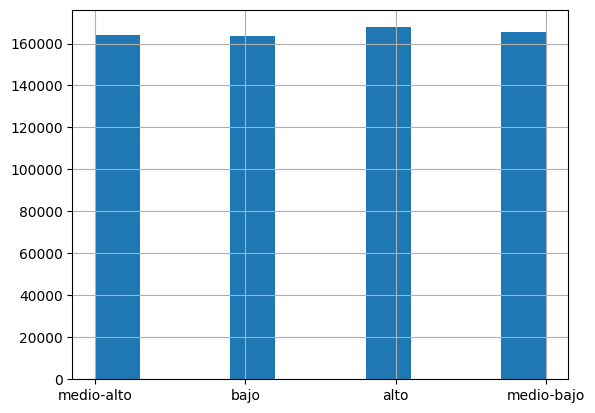

In [95]:
z.RENDIMIENTO_GLOBAL.hist()

**Convertir la columna objetivo (predicción) en valores discretos**

In [96]:
y_col = 'RENDIMIENTO_GLOBAL'

rmap = {'alto': 3, 'bajo':0, 'medio-bajo':1, 'medio-alto':2}
z[y_col] = z[y_col].replace(rmap)
z.head()

/tmp/ipython-input-1309741526.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z[y_col] = z[y_col].replace(rmap)


,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,F_TIENECOMPUTADOR,...,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES,PAGOMATRICULAPROPIO_No,PAGOMATRICULAPROPIO_Si
0,904256,6.0,1.0,3.0,1.0,1.0,Si,Si,N,Si,...,0,0,0,0,0,0,0,0,1,0
1,645256,4.0,0.0,3.0,0.0,1.0,Si,No,N,Si,...,0,0,0,0,0,0,0,0,1,0
2,308367,4.0,4.0,3.0,1.0,1.0,Si,No,N,No,...,0,0,0,0,0,0,0,0,1,0
3,470353,5.0,0.0,4.0,1.0,0.0,Si,No,N,Si,...,0,0,1,0,0,0,0,0,1,0
4,989032,4.0,3.0,3.0,1.0,0.0,Si,Si,N,Si,...,0,0,0,0,0,0,0,0,1,0


**Analisis**

In [97]:
z.dtypes.value_counts()

,count
int64,311
float64,10
object,5


**Preprocesamientos**

Normalización.

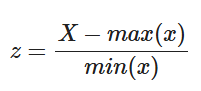

Estandarización.

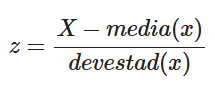

**Selección de caracteristicas**

* Selección Basada en la varianza

from sklearn.feature_selection import VarianceThreshold

# Eliminar características con varianza menor a un umbral
selector = VarianceThreshold(threshold=0.1)
X_selected = selector.fit_transform(X)

* Selección Basada en la Correlacion
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de correlación
corr_matrix = np.corrcoef(X.T)

# Visualizar la matriz de correlación
sns.heatmap(corr_matrix, annot=True)
plt.show()

* Selección Basada en la importacia del modelo
  * Arboles de Decisión
from sklearn.ensemble import RandomForestClassifier

# Entrenar el modelo de Random Forest
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Extraer la importancia de cada característica
importances = model.feature_importances_

# Visualizar las características más importantes
feature_names = df.columns
sorted_indices = np.argsort(importances)[::-1]
plt.bar(range(X.shape[1]), importances[sorted_indices])
plt.xticks(range(X.shape[1]), feature_names[sorted_indices], rotation=90)
plt.show()

  * Random Forest
  * Gradient Boosting
  * XGBoost

from xgboost import XGBClassifier
from xgboost import plot_importance

# Entrenar el modelo XGBoost
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

# Mostrar la importancia de las características
plot_importance(xgb)
plt.show()

* RFE(Metodos recursivos de eliminación)
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Crear un modelo base
model = LogisticRegression()

# Inicializar RFE con el modelo
selector = RFE(estimator=model, n_features_to_select=5, step=1)
selector = selector.fit(X_train, y_train)

# Obtener las características seleccionadas
X_selected = selector.transform(X_train)

* Y faltan...

In [98]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,F_TIENECOMPUTADOR,...,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES,PAGOMATRICULAPROPIO_No,PAGOMATRICULAPROPIO_Si
0,904256,6.0,1.0,3.0,1.0,1.0,Si,Si,N,Si,...,0,0,0,0,0,0,0,0,1,0
1,645256,4.0,0.0,3.0,0.0,1.0,Si,No,N,Si,...,0,0,0,0,0,0,0,0,1,0
2,308367,4.0,4.0,3.0,1.0,1.0,Si,No,N,No,...,0,0,0,0,0,0,0,0,1,0
3,470353,5.0,0.0,4.0,1.0,0.0,Si,No,N,Si,...,0,0,1,0,0,0,0,0,1,0
4,989032,4.0,3.0,3.0,1.0,0.0,Si,Si,N,Si,...,0,0,0,0,0,0,0,0,1,0


In [99]:
z["PRGA_ADMINISTRACION DE SISTEMAS INFORMÁTICOS"].dtype

dtype('int64')

In [100]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,F_TIENECOMPUTADOR,...,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES,PAGOMATRICULAPROPIO_No,PAGOMATRICULAPROPIO_Si
0,904256,6.0,1.0,3.0,1.0,1.0,Si,Si,N,Si,...,0,0,0,0,0,0,0,0,1,0
1,645256,4.0,0.0,3.0,0.0,1.0,Si,No,N,Si,...,0,0,0,0,0,0,0,0,1,0
2,308367,4.0,4.0,3.0,1.0,1.0,Si,No,N,No,...,0,0,0,0,0,0,0,0,1,0
3,470353,5.0,0.0,4.0,1.0,0.0,Si,No,N,Si,...,0,0,1,0,0,0,0,0,1,0
4,989032,4.0,3.0,3.0,1.0,0.0,Si,Si,N,Si,...,0,0,0,0,0,0,0,0,1,0


In [101]:
z.to_csv('preprocesamiento_1.csv', index=False)

**Modelado**

In [102]:
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.metrics import accuracy_score

In [103]:
z.drop(columns=['ID'], inplace=True)
X = z.drop(columns=['RENDIMIENTO_GLOBAL'])
y = z['RENDIMIENTO_GLOBAL']

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [105]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# 1. Separar columnas numéricas y categóricas
cat_cols = X_train.select_dtypes(include=['object']).columns
num_cols = X_train.select_dtypes(exclude=['object']).columns

print("Categóricas:", list(cat_cols))
print("Numéricas :", list(num_cols))

# 2. Preprocesador: one-hot a categóricas, pasar numéricas tal cual
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

# 3. Pipeline completo: preprocesamiento + modelo
clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', DecisionTreeClassifier(random_state=42))
])

# 4. Entrenar
clf = clf.fit(X_train, y_train)

Categóricas: ['F_TIENELAVADORA', 'F_TIENEAUTOMOVIL', 'E_PRIVADO_LIBERTAD', 'F_TIENECOMPUTADOR', 'F_TIENEINTERNET.1']
Numéricas : ['E_VALORMATRICULAUNIVERSIDAD', 'E_HORASSEMANATRABAJA', 'F_ESTRATOVIVIENDA', 'F_TIENEINTERNET', 'F_EDUCACIONPADRE', 'F_EDUCACIONMADRE', 'INDICADOR_1', 'INDICADOR_2', 'INDICADOR_3', 'INDICADOR_4', 'PRGA_ADMINISTRACION DE SISTEMAS INFORMÁTICOS', 'PRGA_ADMINISTRACION INFORMÁTICA', 'PRGA_ADMINISTRACIÓN COMERCIAL', 'PRGA_ADMINISTRACIÓN DE COMERCIO EXTERIOR', 'PRGA_ADMINISTRACIÓN DE EMPRESAS', 'PRGA_ADMINISTRACIÓN DE EMPRESAS AGROINDUSTRIALES', 'PRGA_ADMINISTRACIÓN DE EMPRESAS AGROPECUARIAS', 'PRGA_ADMINISTRACIÓN DE EMPRESAS TURÍSTICAS', 'PRGA_ADMINISTRACIÓN DE EMPRESAS TURÍSTICAS Y HOTELERAS', 'PRGA_ADMINISTRACIÓN DE NEGOCIOS INTERNACIONALES', 'PRGA_ADMINISTRACIÓN DE SERVICIOS DE SALUD', 'PRGA_ADMINISTRACIÓN EN SALUD', 'PRGA_ADMINISTRACIÓN FINANCIERA', 'PRGA_ADMINISTRACIÓN LOGÍSTICA', 'PRGA_ADMINISTRACIÓN MARITIMA Y PORTUARIA', 'PRGA_ADMINISTRACIÓN PÚBLICA', 'PRGA

In [106]:
res_pred = clf.predict(X_test)
score = accuracy_score(y_test, res_pred)
print(f"Accuracy: {score}")

Accuracy: 0.33271313608035336


In [107]:
test.head()

,ID,PERIODO_ACADEMICO,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_TIENEINTERNET.1,F_EDUCACIONMADRE,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4
0,550236,20183,TRABAJO SOCIAL,BOLIVAR,Menos de 500 mil,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Si,No,N,Si,Si,Si,Primaria completa,0.328,0.219,0.317,0.247
1,98545,20203,ADMINISTRACION COMERCIAL Y DE MERCADEO,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,Si,Si,Técnica o tecnológica completa,0.227,0.283,0.296,0.324
2,499179,20212,INGENIERIA MECATRONICA,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Si,No,N,No,Si,Si,Secundaria (Bachillerato) completa,0.285,0.228,0.294,0.247
3,782980,20195,CONTADURIA PUBLICA,SUCRE,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Si,No,N,No,No,No,Primaria incompleta,0.160,0.408,0.217,0.294
4,785185,20212,ADMINISTRACION DE EMPRESAS,ATLANTICO,Entre 2.5 millones y menos de 4 millones,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,Si,Si,Secundaria (Bachillerato) completa,0.209,0.283,0.306,0.286


In [108]:
XTEST = pd.read_csv('preprocesamiento_1.csv')

In [109]:
zt_ids = XTEST['ID'].values

XTEST.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

zt = XTEST.drop(columns=['ID'])
print("shape of loaded dataframe", zt.shape)
zt.head()

shape of loaded dataframe (661080, 325)


,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,F_TIENECOMPUTADOR,F_TIENEINTERNET.1,...,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES,PAGOMATRICULAPROPIO_No,PAGOMATRICULAPROPIO_Si
0,6.0,1.0,3.0,1.0,1.0,Si,Si,N,Si,Si,...,0,0,0,0,0,0,0,0,1,0
1,4.0,0.0,3.0,0.0,1.0,Si,No,N,Si,No,...,0,0,0,0,0,0,0,0,1,0
2,4.0,4.0,3.0,1.0,1.0,Si,No,N,No,Si,...,0,0,0,0,0,0,0,0,1,0
3,5.0,0.0,4.0,1.0,0.0,Si,No,N,Si,Si,...,0,0,1,0,0,0,0,0,1,0
4,4.0,3.0,3.0,1.0,0.0,Si,Si,N,Si,Si,...,0,0,0,0,0,0,0,0,1,0


In [110]:
zt_ids = XTEST['ID'].values

XTEST.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

zt = XTEST.drop(columns=['ID'])
print("shape of loaded dataframe", zt.shape)
zt.head()

shape of loaded dataframe (661080, 325)


,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,F_TIENECOMPUTADOR,F_TIENEINTERNET.1,...,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES,PAGOMATRICULAPROPIO_No,PAGOMATRICULAPROPIO_Si
0,6.0,1.0,3.0,1.0,1.0,Si,Si,N,Si,Si,...,0,0,0,0,0,0,0,0,1,0
1,4.0,0.0,3.0,0.0,1.0,Si,No,N,Si,No,...,0,0,0,0,0,0,0,0,1,0
2,4.0,4.0,3.0,1.0,1.0,Si,No,N,No,Si,...,0,0,0,0,0,0,0,0,1,0
3,5.0,0.0,4.0,1.0,0.0,Si,No,N,Si,Si,...,0,0,1,0,0,0,0,0,1,0
4,4.0,3.0,3.0,1.0,0.0,Si,Si,N,Si,Si,...,0,0,0,0,0,0,0,0,1,0


In [111]:
print(XTEST.columns)   # para ver qué hay

if 'Unnamed: 0' in XTEST.columns:
    XTEST = XTEST.drop(columns=['Unnamed: 0'])

zt_ids = XTEST['ID'].values
zt = XTEST.drop(columns=['ID'])

Index(['ID', 'E_VALORMATRICULAUNIVERSIDAD', 'E_HORASSEMANATRABAJA',
       'F_ESTRATOVIVIENDA', 'F_TIENEINTERNET', 'F_EDUCACIONPADRE',
       'F_TIENELAVADORA', 'F_TIENEAUTOMOVIL', 'E_PRIVADO_LIBERTAD',
       'F_TIENECOMPUTADOR',
       ...
       'DEP_QUINDIO', 'DEP_RISARALDA', 'DEP_SANTANDER', 'DEP_SAN_ANDRES',
       'DEP_SUCRE', 'DEP_TOLIMA', 'DEP_VALLE', 'DEP_VAUPES',
       'PAGOMATRICULAPROPIO_No', 'PAGOMATRICULAPROPIO_Si'],
      dtype='object', length=326)


In [113]:
YTEST = clf.predict(zt)